# Simple SCAM Cases Comparison Plotting Scripts

In [1]:
import matplotlib.pyplot as mp
from matplotlib import gridspec
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter,
                               AutoMinorLocator)
#import seaborn as sb
import numpy as np
import numpy.ma as ma  # masked arroay module
import pandas as pd
import cftime as cft
#import nc_time_axis as nct # Provides pretty time axes on plots

import datetime as dt
import metpy.calc as mpyarm9

In [2]:
from metpy.units import units
import metpy.constants as mconst
import scipy as stats
import os as os
import glob as glob

import xarray as xr
from pylab import *


#from distributed import Client, LocalCluster

# My utils
import scam_utils as scam_utils
import scam_figs as scam_figs
import scam_plot_cnames as scam_cases
import scam_plot_vars as scam_vars

import importlib
#import scam_plot_cases_utils as mypy


In [7]:
'''
    Some plot options
'''


fdpi = 80


# Plots variable
ldiff_plot = False
lvavratio_plot = False
plot_top = 50. # Top of plots in mb.

# 1-hourly
#smooth_tstep = 3 # Timesteps to smooth over for plotting

# 3-hourly
smooth_tstep = 9






Plotting 2D variable ZMDT
Plotting 1D variable PRECT


----------------------------------
Case  1  of  4
** Name =  CAM6-L32
----------------------------------
/glade/work/rneale/scam_cases/cases/ZM_PBL_paper/FSCAM.T42_T42.gateIII.cam6-phys.000.L32/run/FSCAM.T42_T42.gateIII.cam6-phys.000.L32.cam.*
Current case SCAM directory
-File read =  /glade/work/rneale/scam_cases/cases/ZM_PBL_paper/FSCAM.T42_T42.gateIII.cam6-phys.000.L32/run/FSCAM.T42_T42.gateIII.cam6-phys.000.L32.cam.h0i.1974-08-30-00000.nc
-Done...
-Pad dataset to the full IOP period...ARM97 is written out slightly offset it seems (seconds)
-Variable on file, read in -> FSCAM.T42_T42.gateIII.cam6-phys.000.L32

----------------------------------
Case  2  of  4
** Name =  CAM6-L48
----------------------------------
/glade/work/rneale/scam_cases/cases/ZM_PBL_paper/FSCAM.T42_T42.gateIII.cam6-phys.000.L48/run/FSCAM.T42_T42.gateIII.cam6-phys.000.L48.cam.*
Current case SCAM directory
-File read =  /glade/work/rneale/scam_cases/cases/Z

/glade/work/rneale/git/python-scripts/papers/ZM_PBL/cam6_4_032/scam_figs.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cnames_all,rotation=90.)


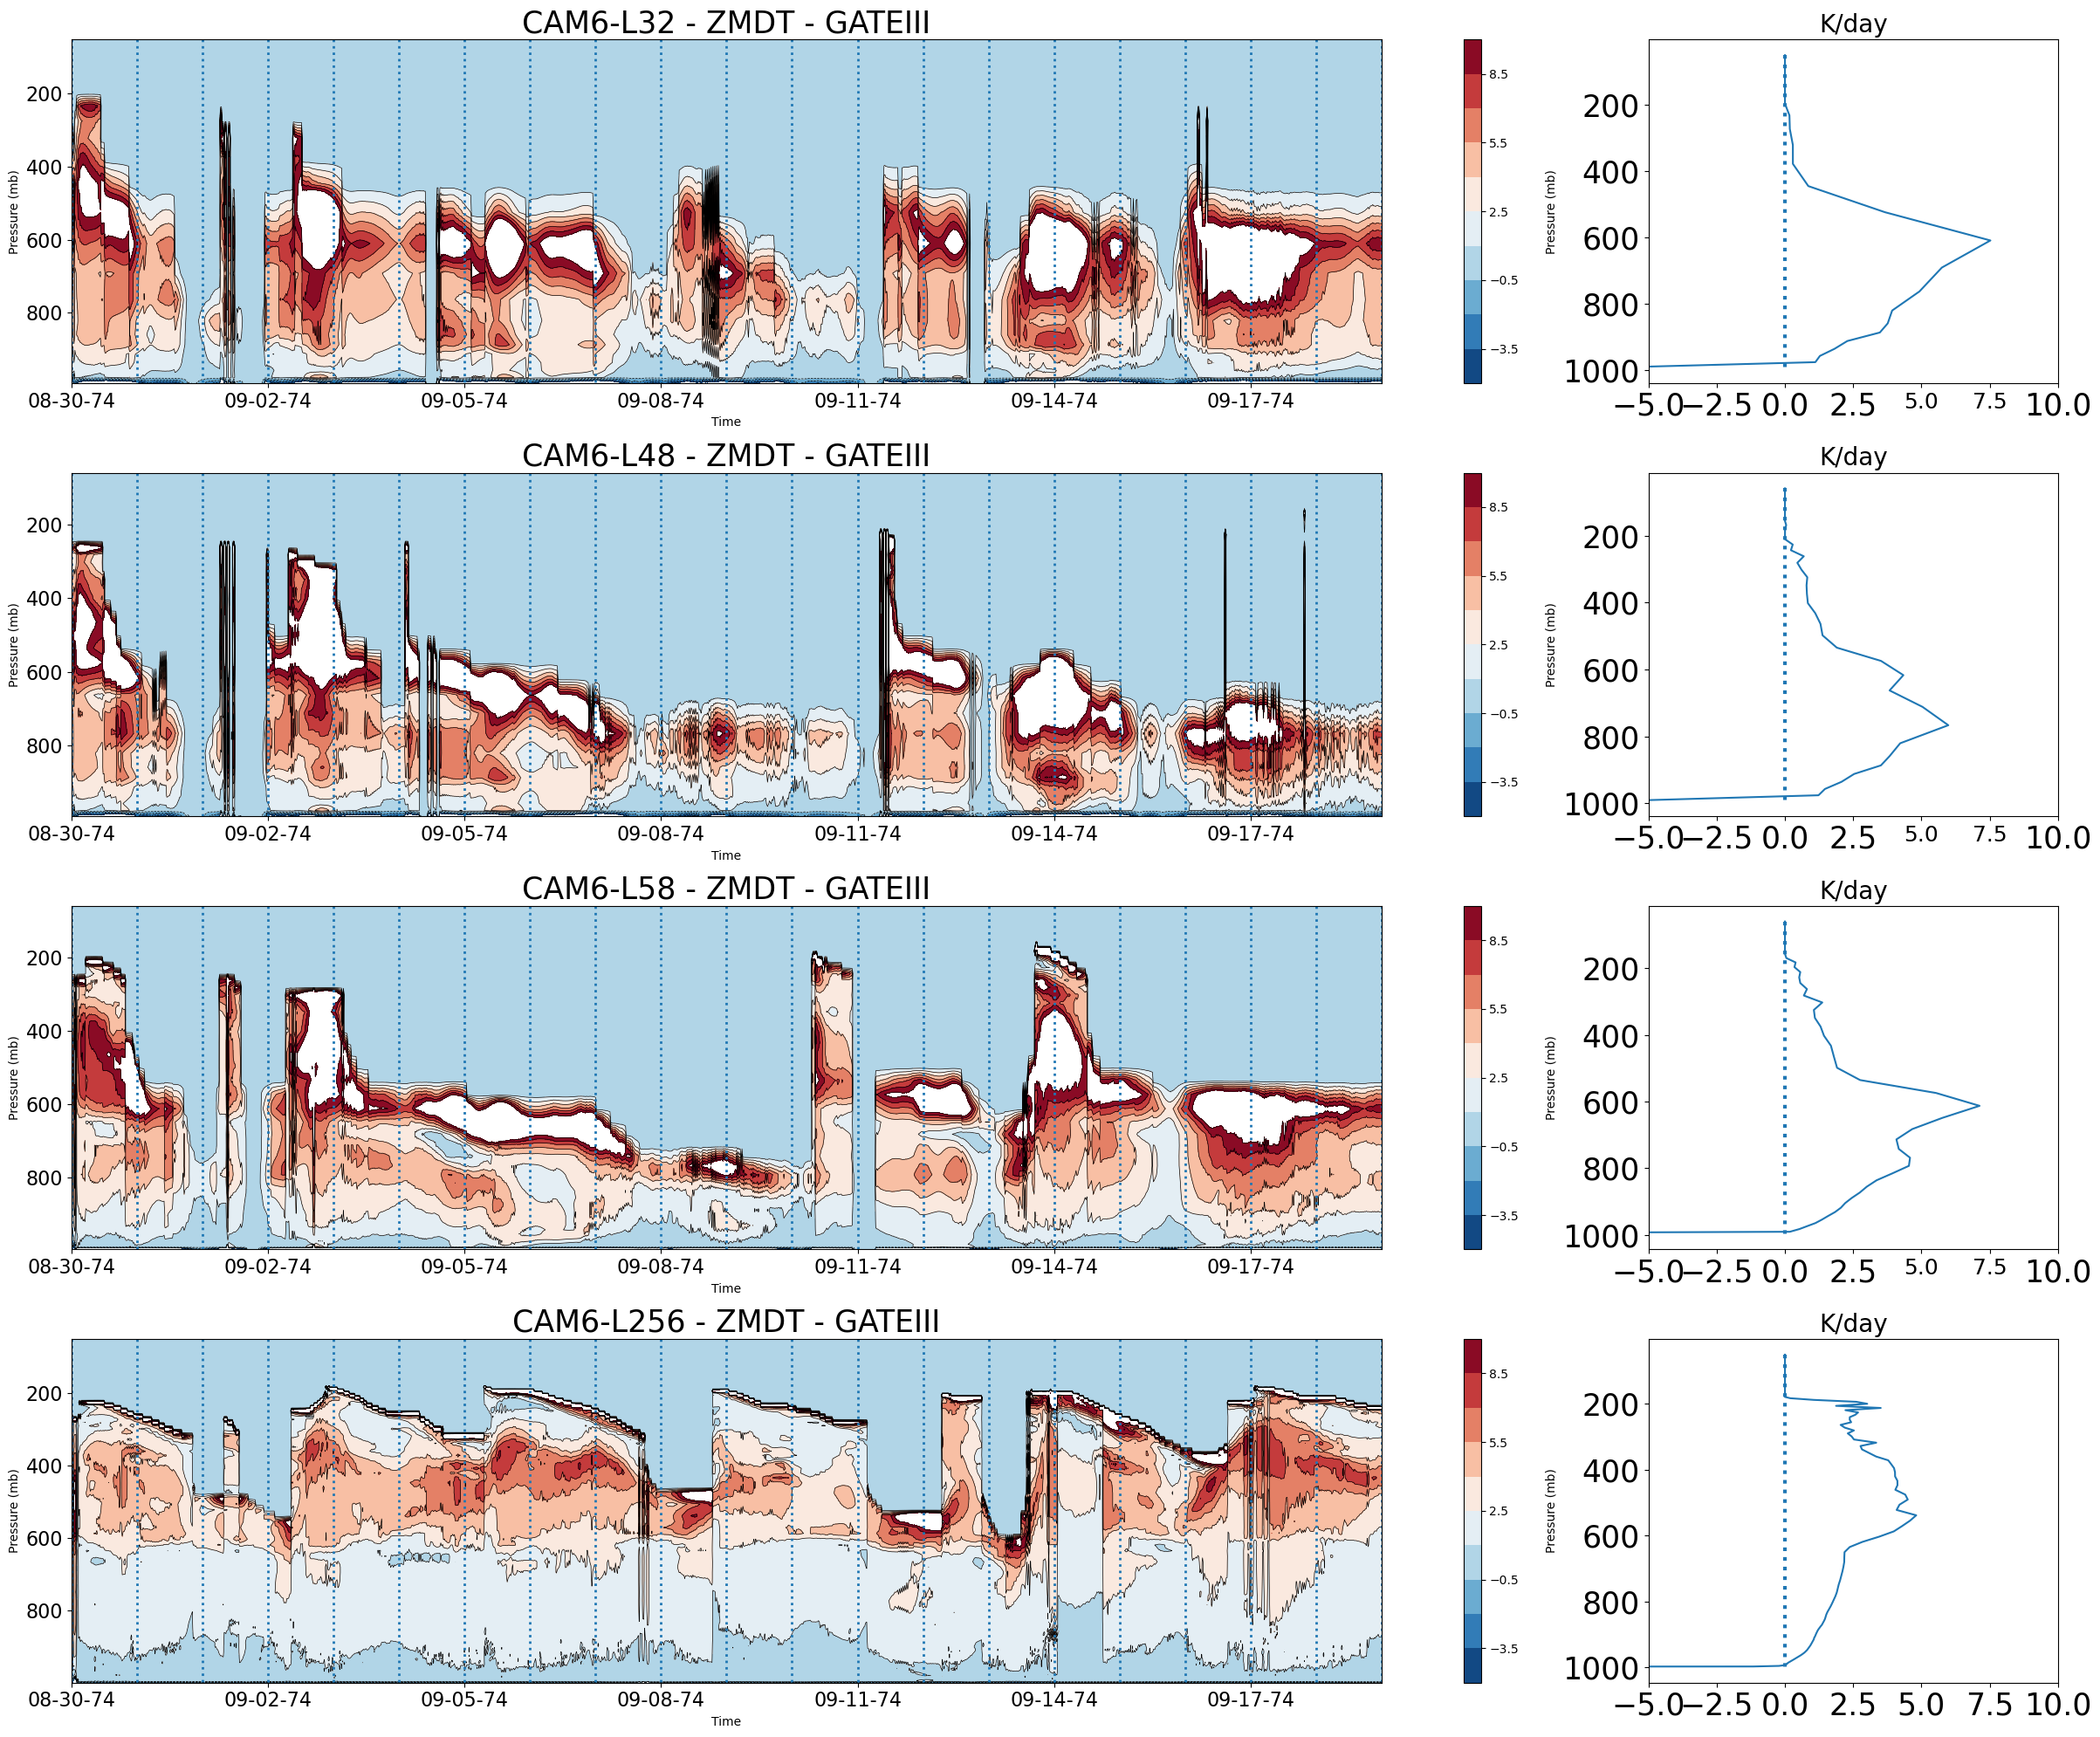

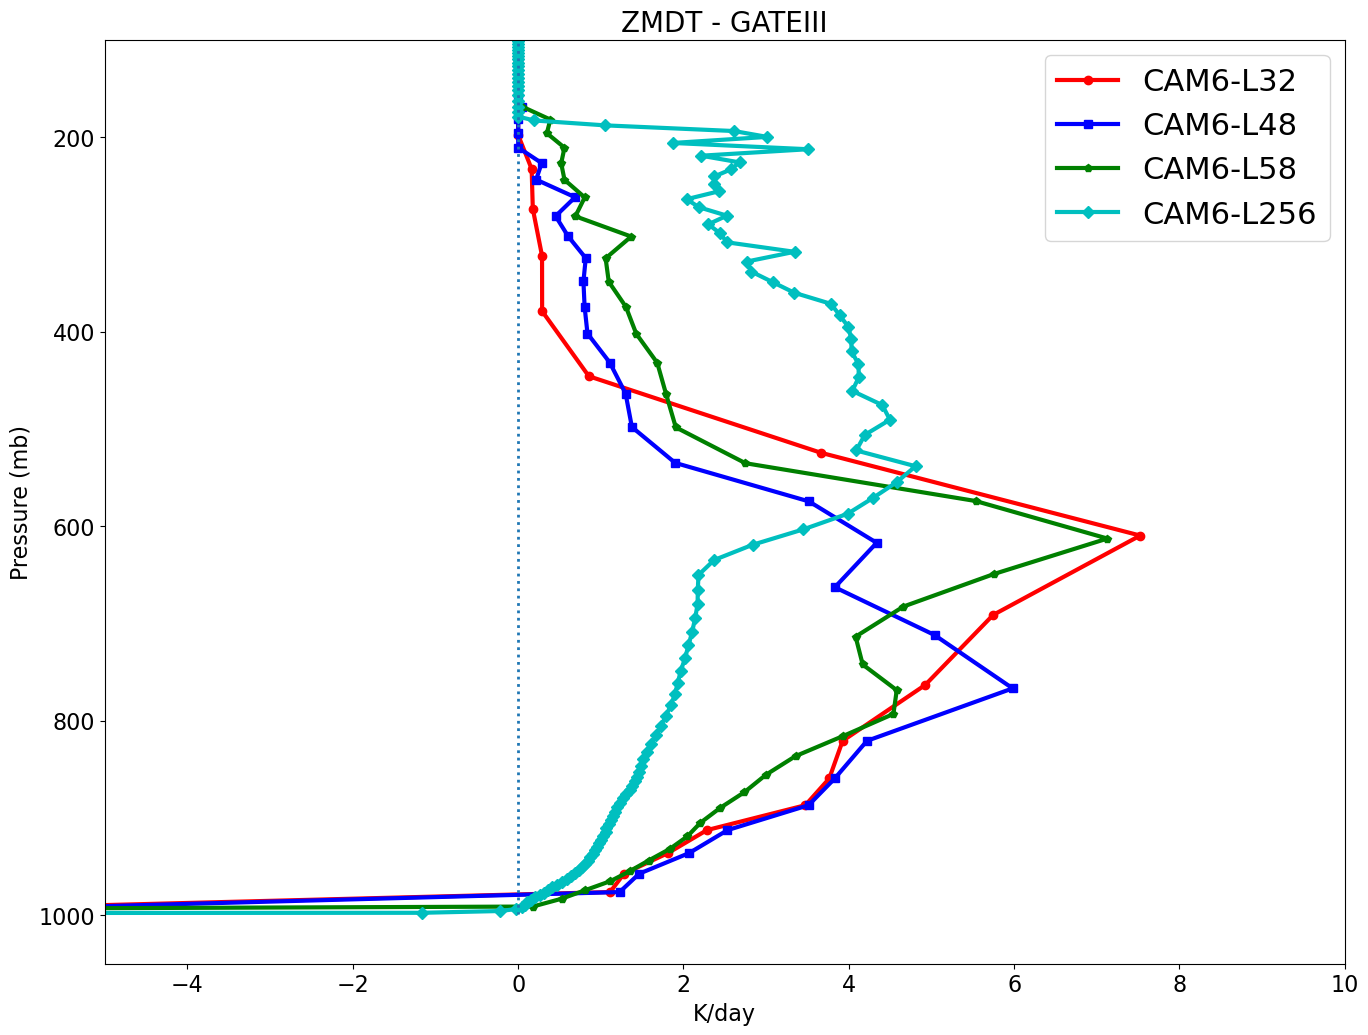

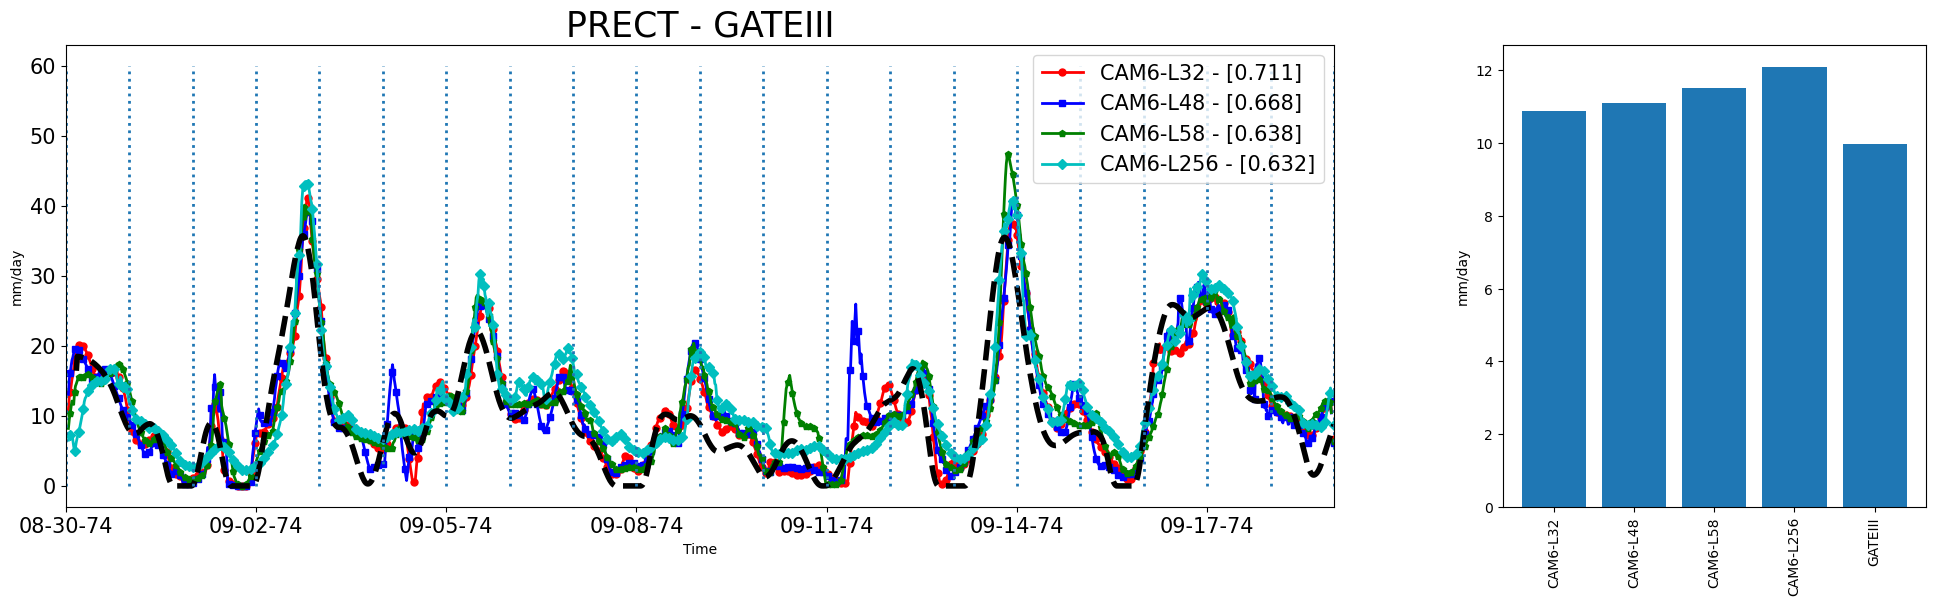

In [9]:
####
importlib.reload(scam_utils) # Required to reload .py files.
importlib.reload(scam_vars)
importlib.reload(scam_cases)
importlib.reload(scam_figs)

## SIMPLE PLOTS ##
my_dir = "/glade/work/rneale/scam_cases/"
pdir = my_dir+"cases/ZM_PBL_paper/"
pdir_cgd = my_dir+"cases_cgd/"
odir = my_dir+"iops/"
#fig_dir = my_dir+"figs/"
fig_dir="/glade/u/home/rneale/python-scripts/python-figs/papers/ZM_PBL/"


## Grab casenames and variables info.

vname, vscale, units2d, cmin, cmax, cmap, ovar2d, ovscale2d, vname1d, vscale1d, units1d, pmin, pmax, ovar1d, ovscale1d = scam_vars.scam_vars_grab()
cases, cnames, fig_pref = scam_cases.scam_cases_grab()



rad_var = ['QRL','QRS']

# Identify IOP

if cases[0].find('togaII')!=-1 : iop = 'TOGAII' 
if cases[0].find('arm97')!=-1  : iop = 'ARM97'
if cases[0].find('arm95')!=-1  : iop = 'ARM95'
if cases[0].find('rico')!=-1  : iop = 'RICO' 
if cases[0].find('gateIII')!=-1 : iop = 'GATEIII' 



lobs1d = False if ovar1d == None else True 
lobs2d = False if ovar2d == None else True 


'''
    SET OBSERVATIONS IF AVAILABLE
'''



### Always read in in obs/iop file to provide padding to the model fields so they can be plotted together garless of time dimension

obs_in = xr.open_dataset(odir+iop+'_4scam.nc',decode_times=False)
obs_in = obs_in.squeeze()

# Make time coord
obs_in = obs_in.rename({'tsec': 'time'})
obs_in = obs_in.set_coords('time')

# Convert time to same as CAM (ultimately use baseti?
base_date = pd.to_datetime(obs_in['bdate'], format='%Y%m%d')
cftime_dates = [cft.DatetimeNoLeap(base_date.year, base_date.month, base_date.day, base_date.hour, base_date.minute, base_date.second) + pd.to_timedelta(seconds, unit='s') for seconds in obs_in.time.values]
obs_in['time'] = cftime_dates






if lobs1d or lobs2d: 
    if iop in ["GATEIII","TOGAII","ARM95"] and ovar1d=='Prec' : ovscale1d = 86400.*1000.
    if lobs1d : var1d_o = ovscale1d*obs_in[ovar1d]
        
    var2d_o = ovscale2d*obs_in[ovar2d] if lobs2d else None

ncases = len(cases)




## Some Plot Environments ##

#plt1, ax1 = mp.subplots(ncases,2, figsize=(24,16), gridspec_kw={'width_ratios': [4, 1]})  # tseries plots
plt1, ax1 = mp.subplots(ncases,2, figsize=(24,ncases*5), gridspec_kw={'width_ratios': [4, 1]})  # tseries plots
plt1.patch.set_facecolor('white')

mp.figure(1)
plt1av, ax1av = mp.subplots(1,1,figsize=(16, 12)) # Ave plot of all cases
mp.figure(2)
plt1d, ax1d = mp.subplots(1,2,figsize=(24, 6),gridspec_kw={'width_ratios': [3, 1]}) # 1D timeseries
mp.figure(3)

plt1.patch.set_facecolor('white')
plt1av.patch.set_facecolor('white')
plt1d.patch.set_facecolor('white')


line_style = ['ro-','bs-','gp-','cD-','mx-','y+-','g*-']


#line_style = ['k','k--','r','b','g','p']



# Edge time points to set to None (// = integer divison)
edge_tstep = smooth_tstep//2-1
nt_noedge = np.r_[0:edge_tstep,-edge_tstep:-1]




print()
print('Plotting 2D variable',vname)
print('Plotting 1D variable',vname1d)
print()




'''
    ################################# 
    #######   LOOP CASES    #########  
    #################################  
'''
    
for ic in range(0,len(cnames)):

    print()
    print('----------------------------------')
    print('Case ',(ic+1),' of ',ncases )
    print('** Name = ',cnames[ic])
    print('----------------------------------')
    
    # Check for standard directory then if in older CGD runs directory
    
    sfile_list = pdir+cases[ic]+"/run/"+cases[ic]+'.cam.*'

    print(sfile_list)
    
    try:   
        sfile = sorted(glob.glob(sfile_list))[0]
        print("Current case SCAM directory")
    except:
        print("CGD case SCAM directory")
        sfile = pdir_cgd+cases[ic]+"/run/"+cases[ic]+'.cam.*'        
        sfile = sorted(glob.glob(sfile_list))[0]


    print('-File read = ',sfile)
    scam_in = xr.open_dataset(sfile,engine='netcdf4')
    scam_in = scam_in.squeeze()
    print('-Done...')



    
    print('-Pad dataset to the full IOP period...ARM97 is written out slightly offset it seems (seconds)')
    scam_in = scam_in.reindex(time=obs_in.time, method="nearest")

  

    if (vname in list(scam_in.keys())):
       

# If a varible doesn't exists just fill with NaNS
    
        print('-Variable on file, read in -> '+cases[ic])
        pvar = scam_in[vname]
 
 
            
    elif [vname in vderived]: # Special variable
        
        print('Derived Variable on file',vname)
        
        if vname=='MSE': # Moist static energy
            pvar = cp_air*scam_in['T'] + Lv*scam_in['Q'] + grav*scam_in['Z3']  
            
    else : # just assign dummy field from T structure
        print('variable not on file, readg T to give dummy variable structure')
        pvar = scam_in['T']
        pvar[:,:] = np.nan
           
    if 'ilev' in list(pvar.dims) : pvar = pvar.rename({'ilev':'lev'}) # Sometimes ilev for e.g., CLUBB vars, change to lev for convenience

    
    
    pvar = pvar.loc[:,plot_top:]    
    pvar = pvar.transpose()*vscale


    
# Pad all cases t the IOP length
#    print(obs_in.time)
#    print(pvar.time)
#    pvar = pvar.reindex(time=obs_in.coords["time"], method=None, fill_value=np.nan)
#    print(pvar)




    
    dlev = (cmax-cmin)/10

    if ic == 0: plevels = np.arange(cmin,cmax+dlev,dlev,dtype=float)


### Time axes lebeling from (annoying) xarray cftime format
    tdate = pvar.time.dt.strftime("%H:%M %m-%d-%Y") # Works for time axis and labeling
    tdate_day = pvar.time.dt.strftime("%m-%d-%y") # Works for time axis and labeling
    
#    nsteps_tick_span = 144
    nsteps_per_day = 72
    nsteps_tick_span = nsteps_per_day*3
    iticks = np.arange(0, len(tdate)+1, nsteps_tick_span)
    itick_days = np.arange(0, len(tdate)+1, nsteps_per_day)
    
    
  










    
    """ ############################ """
    """ ## Timeseries Height Plot ## """
    """ ############################ """

    mp.figure(1)

    
    if var in rad_var:
        pvar = pvar.where(pvar!=0,drop=True)
        
    

    
    plt1 = ax1[ic,0].contourf(tdate,pvar.lev,pvar,levels=plevels,cmap=cmap) 
    plt1 = mp.colorbar(plt1,ax=ax1[ic,0])
    ax1[ic,0].contour(tdate,pvar.lev,pvar,levels=plevels,colors='black',linewidths=0.5) 
#    ax1[ic,0] = mp.add_axes([0.1,0.1,0.75,0.75]) # axis starts at 0.1, 0.1

    ax1[ic,0].set_ylabel('Pressure (mb)') 
    ax1[ic,0].set_xlabel("Time")
 
    for label in (ax1[ic,0].get_xticklabels() + ax1[ic,0].get_yticklabels()):
        label.set_fontsize(16)
   

    ax1[ic,0].set_xticks(iticks)
    ax1[ic,0].set_xticklabels(tdate_day[iticks].values)
    ax1[ic,0].invert_yaxis()  
    ax1[ic,0].vlines(tdate[itick_days], min(pvar.lev),max(pvar.lev), linestyle="dotted",lw=2)
    ax1[ic,0].set_title(cnames[ic]+' - '+vname+' - '+iop,fontsize=25)
    
    mp.tight_layout()
    
    
    
    
    
## Average Plot ##
    pvarm = pvar.mean(axis=1)
    
# Gather 1d timeseries variables
    if vname1d != 'PRECT':
       
        if vname1d == 'PKHMAX' :
            pvar1d = vscale1d*scam_in['KHMAX']
            pvar1d_int = pvar1d.values.astype(int)
            for itt,ill in enumerate(pvar1d_int):  pvar1d[itt] = scam_in.lev[ill-1] 

        else :
            pvar1d = vscale1d*scam_in[vname1d]
      
    else :
        pvar1d = vscale1d*(scam_in['PRECC']+scam_in['PRECL'])
       
    if (vname1d=='LEL') : # Need to change to pressure from level #.

# Convert to int and adjust downwards because of 0/1 indexing difference with fortran.
        ipvar1d = pvar1d.astype(int)-1
        for itt in range(0,len(tdate)) : 
            try:
                pvar1d[itt]=scam_in.lev[ipvar1d[itt]]
            except:
                pvar1d[itt]=pvar1d[itt]

    
    
    if ic == 0 :
        pvarm0 = pvarm
        pvarm_all = pvarm 
        pvarm0 = pvarm # Keep for a normalization plot.
        pvarm_int = pvarm0
        
        lev0 = pvarm.lev
        pvar1d_all = pvar1d # 1D timseries variables
        
    else:

        pvarm_int = pvarm.interp(lev=lev0,method="linear")
        pvarm_all = xr.concat((pvarm_all,pvarm_int),dim='case')  
        pvar1d_all = xr.concat((pvar1d_all,pvar1d),dim='case')  
        
      
    
    
    
    
    
    
        
        

        
        
    """ ########################### """
    """ ## Time-ave Height Plot  ## """
    """ ########################### """

    ax1[ic,1].plot(pvarm,pvarm.lev)
    
    
    ax1[ic,1].set_xlim([1.*cmin,1.*cmax])
    
    ax1[ic,1].set_title(units2d,fontsize = 20)
    ax1[ic,1].tick_params(axis='x', labelsize=18)
    ax1[ic,1].tick_params(axis='y', labelsize=18)
    
    ax1[ic,1].set_ylabel('Pressure (mb)') 
   
    ax1[ic,1].invert_yaxis()  
    
    ax1[ic,1].vlines(0., min(pvar.lev),max(pvar.lev), linestyle="dotted",lw=3)
    
    for label in (ax1[ic,1].get_xticklabels() + ax1[ic,1].get_yticklabels()):
        label.set_fontsize(25)
    
    if lobs2d : # Add obs. and legend w/ obs if needed.
        ax1[ic,1].plot(var2d_o.mean(axis=0),0.01*var2d_o.lev,'ko-')  
        ax1[ic,1].legend(np.append(cnames[ic],iop) if lobs2d else cnames[ic],fontsize=13)
    
    if ic==ncases-1 : 
        mp.figure(1)
        mp.savefig(fig_dir+cases[0]+'.'+fig_pref+'_scam_ts_'+vname+'.png', dpi=fdpi,facecolor='white') # If last tseries plot then output.
    
# Average profiles
    mp.figure(2)
    
    if lvavratio_plot : # Ratio of first case 
        vav_pvar = pvarm_int/pvarm0 
        vav_plev = pvarm0.lev
        vav_vline = 1.
    else: # Regular plot
        vav_pvar = pvarm
        vav_plev = pvarm.lev
        vav_vline = 0.

    '''
     ################################### 
     ##   Plot 2D Case Average     ## 
     ###################################
     '''
    
    
    ax1av.plot(vav_pvar,vav_plev,line_style[ic],lw=3)

# 1D timeseries
    mp.figure(3)
 

#### STICK IN THE 1D TIMSERIES HERE ######


    
    pvar1d_ma = pvar1d.copy()
    pvar1d_ma.values = scam_utils.moving_average(pvar1d,smooth_tstep) if smooth_tstep >1 else pvar1d_ma.values
    pvar1d_ma[nt_noedge] = None

#    if ic == 0:
#        pvar1d_save = pvar1d_ma.values
#    else:
#        for idx, value in enumerate(pvar1d_ma.values-pvar1d_save):
#            print(f"{idx}: {value}: {pvar1d_save[idx]}")
        

    '''
     ################################### 
     ##   Plot 1D Case Timeseries     ## 
     ################################### 
    '''   
    
    ax1d[0].plot(tdate,pvar1d_ma,line_style[ic],lw=2,markersize=5,markevery=5)


  


'''
################################################### 
############## END MAIN CASE LOOP ################# 
################################################### 
'''








'''
 ########################### 
 ##   Average 2D Plot     ## 
 ########################### 
'''

mp.figure(2)

if lobs2d: ax1av.plot(var2d_o.mean(axis=0),0.01*var2d_o.lev,'ko-',lw=0.5)
ax1av.set_ylabel('Pressure (mb)',fontsize=16) 
ax1av.set_xlim([1.*cmin,1.*cmax])

ax1av.set_xlabel(units2d,fontsize=16) 
ax1av.set_ylim([100,1050])

ax1av.tick_params(axis='x', labelsize=14)
ax1av.tick_params(axis='y', labelsize=14)

ax1av.set_title(vname+' - '+iop,fontsize=20)
ax1av.vlines(vav_vline, min(pvar.lev),max(pvar.lev), linestyle="dotted",lw=2)
ax1av.invert_yaxis()  
ax1av.legend(np.append(cnames,iop) if lobs2d else cnames,fontsize=22)
#ax1av.set_yscale('log')
                            
for label in (ax1av.get_xticklabels() + ax1av.get_yticklabels()):
        label.set_fontsize(16)

# % age difference plot.
#ax1av[1].plot(100.*pvarm_all[1].transpose()/pvarm_all[0].transpose(),pvarm_all.lev)  

### 2D RATIO OF CASE2/CASE1 ###

#ax1av[1].set_title('100*case2/case1',fontsize=20)
#ax1av[1].set_xlabel('%') 

#ax1av[1].vlines(100., min(pvar.lev),max(pvar.lev), linestyle="dotted",lw=2)
#ax1av[1].invert_yaxis()

mp.savefig(fig_dir+cases[0]+'.'+fig_pref+'_scam_aves_'+vname+'.png', dpi=fdpi)








""" ########################### """
""" ##   Timeseries 1D Plot   ## """
""" ########################### """


# Plot obs

if lobs1d:
    cnames_all = np.append(cnames,iop)
#    pvar1d_all = np.append(pvar1d_all,var1d_o.values) 
    pvar1d_all = np.vstack([pvar1d_all,[var1d_o.values]])
else:
    cnames_all = np.array(cnames)
    pvar1d_all = pvar1d_all




#ax1d[0].plot(tdate,moving_average(pvar_all[0,:].transpose(),10))  

## Still might need to solve the date problem
#odate = pd.to_datetime('19970514.567', format='%Y%m%d')
#date_o = var_o.time.dt.strftime("%H:%M %m-%d-%Y") 
#odate = [cftime.datetime(year=2017, month=2, day=n) for n in range(1, 31)]
#odate = dt.date(year=obs_in.year, month=obs_in.month, day=obs_in.day
#date_o = var_o.time.dt.strftime("%H:%M %m-%d-%Y") 

mp.figure(3)



""" ############################################################ """
""" ##   Plot Timeseries of 1D Observations (if available)    ## """
""" ############################################################ """


cnames_all_ts = cnames_all


if lobs1d:
    
    pvar1d_mo = var1d_o.copy()
    pvar1d_mo.values = scam_utils.moving_average(var1d_o,smooth_tstep) if smooth_tstep >1 else pvar1d_mo.values
    pvar1d_mo[nt_noedge] = None
    
#    ax1d[0].plot(tdate,pvar1d_mo,'o:k','k',markevery=4,lw=4)  # Line=black with x's [kx]

    if iop == 'GATEIII' and vname1d == 'PRECT': # Offset prect data as it is a water budget derived quantity that should have a delay of 3-6 hours
        tshift = 9 # 9 = 3 hours
        pvar1d_mo = (pvar1d_mo.shift(time=tshift).reindex(time=pvar1d_mo.time))
    
    ax1d[0].plot(tdate,pvar1d_mo,'k',lw=4,linestyle="dashed")  

    pvar1d_np = np.array(pvar1d_all)
    

    cnames_all_ts=[]
    for ii in range(0,ncases):


        #corr_case = np.corrcoef(pvar1d_np[ii,:],var1d_o.data)
        corr_case = scam_utils.corrcoef_ignore_nan(pvar1d_np[ii,:],var1d_o.data)
        
        corr_val = corr_case.data        
        cnames_all_ts.append(cnames_all[ii]+' - [%s]'%np.round(corr_val,decimals=3))
        

ax1d[0].legend(cnames_all_ts,fontsize=15)


for label in (ax1d[0].get_xticklabels() + ax1d[0].get_yticklabels()):
        label.set_fontsize(15)

ax1d[0].set_xlabel("Time")
ax1d[0].set_ylabel(units1d) 

#ax1d[0].set_ylim([pmin,pmax])
ax1d[0].set_xlim([tdate[0],tdate[-1]])

#ax1d[0].set_xticks(np.arange(0, len(tdate)+1, pntspan))
ax1d[0].set_xticks(iticks)
ax1d[0].set_xticklabels(tdate_day[iticks].values)

ax1d[0].vlines(tdate[itick_days], pmin,pmax, linestyle="dotted",lw=2)

# ax1d[0].xaxis.set_minor_locator(MultipleLocator(360))
# ax1d[0].xaxis.set_major_locator(MultipleLocator(72))
ax1d[0].set_title(vname1d+' - '+iop,fontsize=25)



if vname1d == 'LEL':
    
#    lel_range = np.arange(pvar_all.values.min()PKHMAS,pvar_all.values.max()) # Range of lel
#    lel_range = lel_range.astype(int)

#    ax1d[0].set_yticks(lel_range)
#    ax1d[0].set_yticklabels(scam_in.lev[lel_range].values.astype(int))
    
    ax1d[0].invert_yaxis()

if vname1d in ['PLCL','PKHMAX']: ax1d[0].invert_yaxis()


""" ########################### """
""" ### Average bar chart ##### """
""" ########################### """


scam_figs.scam_bar(ax1d[1],pvar1d_all,cnames_all,units1d)
mp.savefig(fig_dir+cases[0]+'.'+fig_pref+'_scam_1d_'+vname1d+'.png', dpi=fdpi)
